Última fecha histórica: 2023-08-31
Horizonte de pronóstico calculado: 122 días (hasta 2023-12-31)


18:40:01 - cmdstanpy - INFO - Chain [1] start processing
18:40:02 - cmdstanpy - INFO - Chain [1] done processing
18:40:03 - cmdstanpy - INFO - Chain [1] start processing
18:40:05 - cmdstanpy - INFO - Chain [1] done processing
18:40:06 - cmdstanpy - INFO - Chain [1] start processing
18:40:07 - cmdstanpy - INFO - Chain [1] done processing
18:40:08 - cmdstanpy - INFO - Chain [1] start processing
18:40:08 - cmdstanpy - INFO - Chain [1] done processing
18:40:09 - cmdstanpy - INFO - Chain [1] start processing
18:40:09 - cmdstanpy - INFO - Chain [1] done processing



Rango de fechas pronosticadas: 2023-09-01 00:00:00 → 2023-12-31 00:00:00
Días pronosticados por equipo: {'Price_Equipo1': 122, 'Price_Equipo2': 122}

=== Coeficientes de Prophet por insumo y equipo (segunda fuente de evidencia) ===
           Equipo_1  Equipo_2  Equipo_1_abs  Equipo_2_abs
regressor                                                
Price_Y    0.801804  0.337835      0.801804      0.337835
Price_X    0.201078  0.363485      0.201078      0.363485
Price_Z   -0.000588  0.330409      0.000588      0.330409

=== Comparación RandomForest (Notebook 2) vs Prophet (este notebook) ===
RandomForest (importancia relativa):
        Variable  Equipo_1  Equipo_2
0        Price_Y  0.991642  0.024649
1        Price_X  0.002855  0.009763
2  Price_X_lag30  0.001793  0.003157
3        Price_Z  0.001545  0.957527
4  Price_Z_lag30  0.001487  0.002520
5  Price_Y_lag30  0.000678  0.002385

Prophet (coeficiente absoluto):
           Equipo_1_abs  Equipo_2_abs
regressor                           

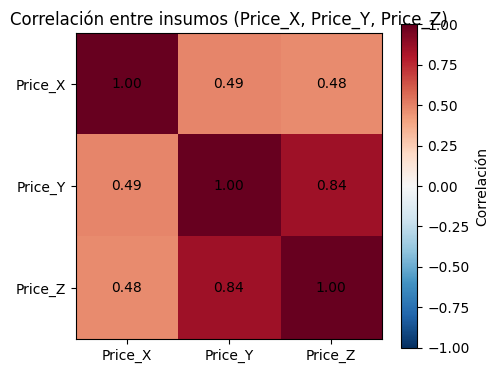

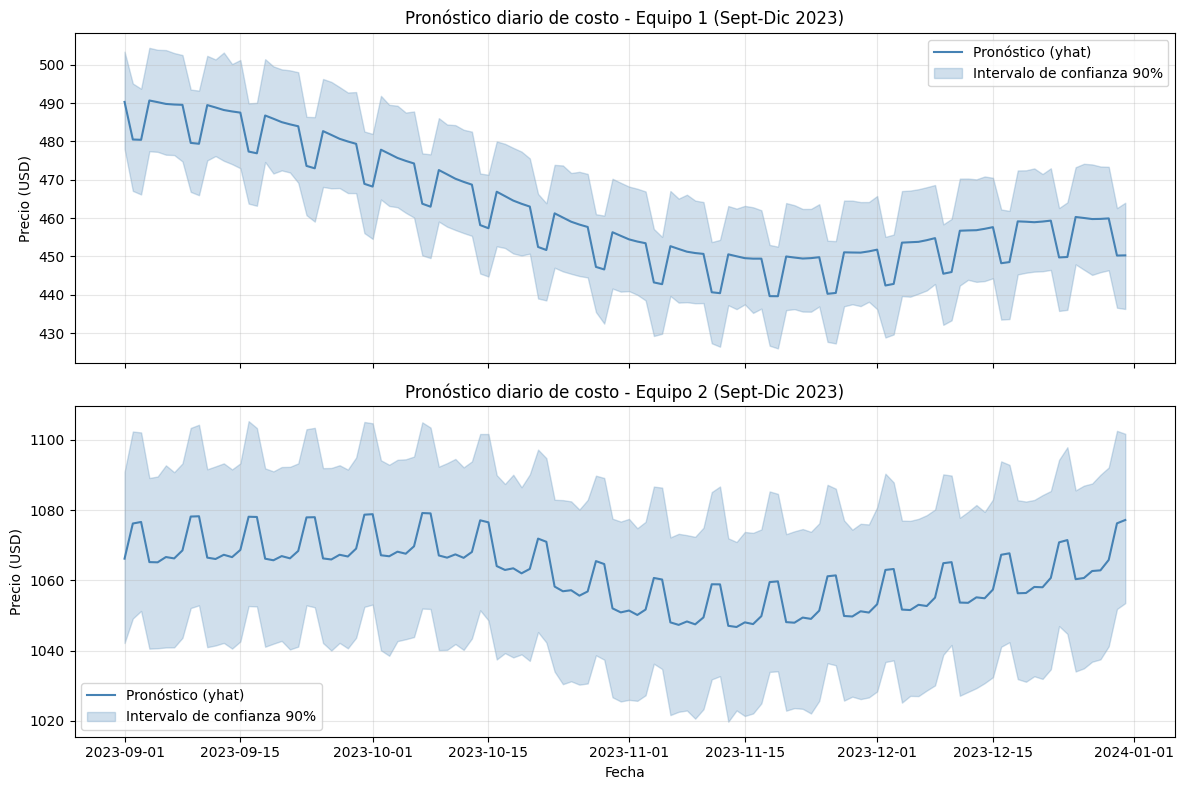


=== Resumen mensual del pronóstico por equipo ===
          Equipo      Mes     Promedio       Minimo       Maximo
0  Price_Equipo1  2023-09   483.401872   468.924576   490.670503
1  Price_Equipo1  2023-10   463.615493   446.592623   477.831958
2  Price_Equipo1  2023-11   448.257984   439.611906   454.438630
3  Price_Equipo1  2023-12   454.050008   442.408439   460.277090
4  Price_Equipo2  2023-09  1070.060890  1065.134910  1078.705510
5  Price_Equipo2  2023-10  1065.869687  1050.870066  1079.172490
6  Price_Equipo2  2023-11  1052.022006  1046.709279  1061.412424
7  Price_Equipo2  2023-12  1060.668394  1051.536869  1077.186447


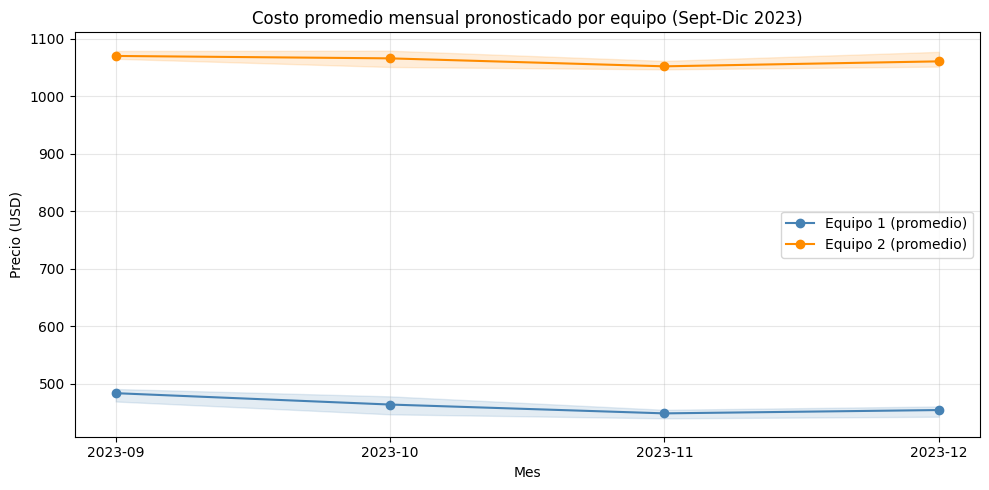

In [0]:
import pandas as pd
from datetime import date
from prophet import Prophet
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

# 1. Leer los datos históricos (SIN AGRUPAR, mantenemos el nivel diario de origen)
df_pd = spark.read.table("proyecto_gestion_costos_operativos.default.silver_equipos").toPandas()
df_pd['Date'] = pd.to_datetime(df_pd['Date'])

max_date_hist = df_pd['Date'].max()  # Timestamp, se usa para filtrar el forecast final

# pronosticar TODOS los días de cada uno de los 4 meses. Ahora se calcula
# dinámicamente contra la fecha objetivo del proyecto.
fecha_fin_pronostico = date(2023, 12, 31)
horizonte_dias = (fecha_fin_pronostico - max_date_hist.date()).days

print(f"Última fecha histórica: {max_date_hist.date()}")
print(f"Horizonte de pronóstico calculado: {horizonte_dias} días (hasta {fecha_fin_pronostico})")


# 2. Función para proyectar las materias primas día a día
def proyectar_exogena(columna):
    df_ex = df_pd[['Date', columna]].rename(columns={'Date': 'ds', columna: 'y'})
    model_ex = Prophet(daily_seasonality=True).fit(df_ex)
    future = model_ex.make_future_dataframe(periods=horizonte_dias, freq='D')
    forecast = model_ex.predict(future)
    return forecast[['ds', 'yhat']].rename(columns={'yhat': columna})


forecast_x = proyectar_exogena('Price_X')
forecast_y = proyectar_exogena('Price_Y')
forecast_z = proyectar_exogena('Price_Z')

future_exogenas = forecast_x.merge(forecast_y, on='ds').merge(forecast_z, on='ds')


# 3. Función de forecasting multivariable diario para los Equipos
def pronosticar_equipo(columna_equipo):
    df_eq = df_pd[['Date', columna_equipo, 'Price_X', 'Price_Y', 'Price_Z']].rename(
        columns={'Date': 'ds', columna_equipo: 'y'}
    )

    model_eq = Prophet(interval_width=0.90, daily_seasonality=True)
    model_eq.add_regressor('Price_X')
    model_eq.add_regressor('Price_Y')
    model_eq.add_regressor('Price_Z')
    model_eq.fit(df_eq)

    future_eq = model_eq.make_future_dataframe(periods=horizonte_dias, freq='D')
    future_eq = future_eq.merge(future_exogenas, on='ds', how='left')

    forecast = model_eq.predict(future_eq)

    resultados = forecast[forecast['ds'] > max_date_hist][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
    resultados['Equipo'] = columna_equipo
    return resultados, model_eq  # AGREGADO: se devuelve también el modelo ya entrenado


res_eq1, modelo_eq1 = pronosticar_equipo('Price_Equipo1')
res_eq2, modelo_eq2 = pronosticar_equipo('Price_Equipo2')

df_resultados = pd.concat([res_eq1, res_eq2])

#  confirma que efectivamente se cubrieron los 4 meses completos
print("\nRango de fechas pronosticadas:", df_resultados['ds'].min(), "→", df_resultados['ds'].max())
print("Días pronosticados por equipo:", df_resultados.groupby('Equipo')['ds'].count().to_dict())

# 4. Sobrescribir la tabla en Databricks con los datos DIARIOS generados
df_spark_resultados = spark.createDataFrame(df_resultados)
df_spark_resultados.write.format("delta").mode("overwrite").saveAsTable(
    "proyecto_gestion_costos_operativos.default.predicciones_4_meses"
)

# -------------------------------------------------------------------------
# AGREGADO: segunda fuente de evidencia de "señal vs ruido" por equipo.

from prophet.utilities import regressor_coefficients

coef_eq1 = regressor_coefficients(modelo_eq1)[['regressor', 'coef']].rename(columns={'coef': 'Equipo_1'})
coef_eq2 = regressor_coefficients(modelo_eq2)[['regressor', 'coef']].rename(columns={'coef': 'Equipo_2'})

comparacion_coeficientes = coef_eq1.merge(coef_eq2, on='regressor').set_index('regressor')
# Se compara por magnitud absoluta: el signo indica si el efecto es directo o
# inverso, pero para "qué tanto pesa" lo relevante es el tamaño del coeficiente.
comparacion_coeficientes['Equipo_1_abs'] = comparacion_coeficientes['Equipo_1'].abs()
comparacion_coeficientes['Equipo_2_abs'] = comparacion_coeficientes['Equipo_2'].abs()

print("\n=== Coeficientes de Prophet por insumo y equipo (segunda fuente de evidencia) ===")
print(comparacion_coeficientes.sort_values('Equipo_1_abs', ascending=False))


spark.createDataFrame(
    comparacion_coeficientes.reset_index()
).write.format("delta").mode("overwrite").saveAsTable(
    "proyecto_gestion_costos_operativos.default.coeficientes_prophet_por_equipo"
)

try:
    df_importancia_rf = spark.read.table(
        "proyecto_gestion_costos_operativos.default.importancia_variables_por_equipo"
    ).toPandas()
    print("\n=== Comparación RandomForest (Notebook 2) vs Prophet (este notebook) ===")
    print("RandomForest (importancia relativa):")
    print(df_importancia_rf)
    print("\nProphet (coeficiente absoluto):")
    print(comparacion_coeficientes[['Equipo_1_abs', 'Equipo_2_abs']])
    print("\nRevisa manualmente si ambos métodos apuntan al mismo insumo como el más determinante por equipo.")
except Exception:
    print("\nNota: corre primero el Notebook 2 para poder comparar contra la tabla de importancia del RandomForest.")

# -------------------------------------------------------------------------
# AGREGADO: matriz de correlación entre los insumos.

import matplotlib.pyplot as plt
import numpy as np

matriz_correlacion = df_pd[['Price_X', 'Price_Y', 'Price_Z']].corr()
print("\n=== Matriz de correlación entre insumos (historico) ===")
print(matriz_correlacion)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(matriz_correlacion, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(matriz_correlacion.columns)))
ax.set_yticks(range(len(matriz_correlacion.columns)))
ax.set_xticklabels(matriz_correlacion.columns)
ax.set_yticklabels(matriz_correlacion.columns)
for i in range(len(matriz_correlacion.columns)):
    for j in range(len(matriz_correlacion.columns)):
        ax.text(j, i, f"{matriz_correlacion.iloc[i, j]:.2f}", ha='center', va='center', color='black')
ax.set_title("Correlación entre insumos (Price_X, Price_Y, Price_Z)")
fig.colorbar(im, ax=ax, label="Correlación")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# AGREGADO: visualización diaria del pronóstico por equipo, con banda de
# confianza del 90%
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for ax, (equipo, nombre) in zip(axes, [('Price_Equipo1', 'Equipo 1'), ('Price_Equipo2', 'Equipo 2')]):
    df_eq_plot = df_resultados[df_resultados['Equipo'] == equipo].sort_values('ds')
    ax.plot(df_eq_plot['ds'], df_eq_plot['yhat'], label='Pronóstico (yhat)', color='steelblue')
    ax.fill_between(
        df_eq_plot['ds'], df_eq_plot['yhat_lower'], df_eq_plot['yhat_upper'],
        alpha=0.25, color='steelblue', label='Intervalo de confianza 90%'
    )
    ax.set_title(f"Pronóstico diario de costo - {nombre} (Sept-Dic 2023)")
    ax.set_ylabel("Precio (USD)")
    ax.legend()
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Fecha")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# AGREGADO: resumen mensual por equipo (promedio, mínimo, máximo por mes).
# -------------------------------------------------------------------------
df_resultados['Mes'] = df_resultados['ds'].dt.to_period('M').astype(str)

resumen_mensual = df_resultados.groupby(['Equipo', 'Mes']).agg(
    Promedio=('yhat', 'mean'),
    Minimo=('yhat', 'min'),
    Maximo=('yhat', 'max'),
).reset_index()

print("\n=== Resumen mensual del pronóstico por equipo ===")
print(resumen_mensual)

fig, ax = plt.subplots(figsize=(10, 5))
for equipo, nombre, color in [('Price_Equipo1', 'Equipo 1', 'steelblue'), ('Price_Equipo2', 'Equipo 2', 'darkorange')]:
    df_eq_mensual = resumen_mensual[resumen_mensual['Equipo'] == equipo]
    ax.plot(df_eq_mensual['Mes'], df_eq_mensual['Promedio'], marker='o', label=f"{nombre} (promedio)", color=color)
    ax.fill_between(
        df_eq_mensual['Mes'], df_eq_mensual['Minimo'], df_eq_mensual['Maximo'],
        alpha=0.15, color=color
    )

ax.set_title("Costo promedio mensual pronosticado por equipo (Sept-Dic 2023)")
ax.set_ylabel("Precio (USD)")
ax.set_xlabel("Mes")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()